In [2]:
import asyncio, json, os
import websockets
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import geodatasets
import tqdm as notebook_tqdm
import contextily as cx

In [3]:
# load the ports from ports.csv
ports_df = pd.read_csv('data/Ports.csv')
choke_points_df = pd.read_csv('data/PortWatch_Chokepoints_database.csv')
combined_df = pd.concat([ports_df, choke_points_df], ignore_index=True)

In [4]:
# for each port in the combined_df, add a new column called bounding box that contains the bounding box of the port in the format (min_lat, min_lon, max_lat, max_lon) within 15km
combined_df['bounding_box'] = None  
for index, row in combined_df.iterrows():
    lat = row['lat']
    lon = row['lon']
    min_lat = lat - 0.135
    max_lat = lat + 0.135
    min_lon = lon - 0.135
    max_lon = lon + 0.135
    combined_df.at[index, 'bounding_box'] = (min_lat, min_lon, max_lat, max_lon)

In [5]:
combined_df.head(10)

,X,Y,portid,portname,country,ISO3,fullname,lat,lon,pageid,ObjectId,bounding_box
0,1.514731e+07,4.254924e+06,port1325,Tsuruga,Japan,JPN,"Tsuruga, Japan",35.667194,136.070611,3b1f40eb8acd452ab6229331302891fe,1,"(35.53219379, 135.9356107, 35.80219379, 136.20..."
1,1.099633e+07,1.931654e+05,port1198,Sibolga,Indonesia,IDN,"Sibolga, Indonesia",1.734969,98.781715,4d00b008b4be4068bf8a19d7da6e8cf6,2,"(1.599969159, 98.64671534, 1.869969159, 98.916..."
2,1.206306e+07,2.465269e+06,port339,Fangcheng,China,CHN,"Fangcheng, China",21.614205,108.364339,266042b244cf452a89f4a2de14f3da2f,3,"(21.47920534, 108.22933929999999, 21.749205340..."
3,1.460658e+07,4.021402e+06,port1335,Ube,Japan,JPN,"Ube, Japan",33.944875,131.213184,f3f6725ef00e4d3f8f9c93c45258667e,4,"(33.80987467, 131.0781838, 34.079874669999995,..."
4,1.874177e+07,-5.875428e+06,port153,Bluff Harbor,New Zealand,NZL,"Bluff Harbor, New Zealand",-46.590130,168.360216,894ab5e5a18e48b6922c023196f74c8f,5,"(-46.725129949999996, 168.22521600000002, -46...."
5,-1.642044e+05,7.359181e+06,port1334,Tynemouth,United Kingdom,GBR,"Tynemouth, United Kingdom",54.986163,-1.475073,c5c5cc67df43466e999530930e8425d1,6,"(54.85116295, -1.610073161, 55.12116295, -1.34..."
6,1.343949e+07,4.551049e+06,port897,Penglai,China,CHN,"Penglai, China",37.798850,120.728976,0f79b45e2a6b466682a3e2c4d5d8d3df,7,"(37.66385005, 120.5939755, 37.93385005, 120.86..."
7,1.693740e+06,3.808549e+06,port750,Misrata,Libya,LBY,"Misrata, Libya",32.343984,15.215128,70d1343f8a804a53bd7d766c3dbed671,8,"(32.208983790000005, 15.08012828, 32.47898379,..."
8,5.360523e+06,3.560699e+06,port563,Khorramshahr,Iran,IRN,"Khorramshahr, Iran",30.443603,48.154400,0c2107f4770842e4b68a3986bb94b6c4,9,"(30.308603339999998, 48.01939964, 30.57860334,..."
9,1.491386e+07,4.105068e+06,port1343,Uno,Japan,JPN,"Uno, Japan",34.566078,133.973469,2ab531a159ee4add8bb76a491e2cf25b,10,"(34.43107811, 133.8384693, 34.70107811, 134.10..."


In [6]:
import os
import json
import asyncio
import websockets
import pandas as pd

# 1. Setup port and bounding box
target_port_name = "Amsterdam"  # Change to your port
port_row = combined_df[combined_df["portname"] == target_port_name].iloc[0]
min_lat, min_lon, max_lat, max_lon = port_row["bounding_box"]
API_KEY = os.getenv("AISSTREAM_API_KEY")

# 2. Set duration (Increased because static data broadcasts less frequently)
STREAM_DURATION_SECONDS = 300 

async def stream_static_data(duration):
    data_list = []
    
    try:
        async with websockets.connect(
            "wss://stream.aisstream.io/v0/stream",
            compression="deflate",
        ) as ws:
            
            # Send subscription request for ShipStaticData ONLY
            await ws.send(json.dumps({
                "APIKey": API_KEY,
                "BoundingBoxes": [[[min_lat, min_lon], [max_lat, max_lon]]],
                "FilterMessageTypes": ["ShipStaticData"]
            }))
            
            print(f"Stream opened. Waiting {duration} seconds for static data...")

            async def receive_messages():
                async for payload in ws:
                    msg = json.loads(payload)
                    
                    if msg.get("MessageType") == "ShipStaticData":
                        meta = msg.get("MetaData", {})
                        report = msg.get("Message", {}).get("ShipStaticData", {})
                        
                        # Flatten dictionaries
                        row_data = {**meta, **report}
                        data_list.append(row_data)
                        
                        # Optional: Print names as they arrive so you know it's working
                        ship_name = meta.get("ShipName", "Unknown").strip()
                        print(f"Caught static data for: {ship_name}")

            # Enforce the time limit
            await asyncio.wait_for(receive_messages(), timeout=duration)
            
    except asyncio.TimeoutError:
        print("\nTime limit reached. Closing stream.")
    except Exception as e:
        print(f"An error occurred: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    return df

# Await the function and store the result
static_df = await stream_static_data(STREAM_DURATION_SECONDS)

Stream opened. Waiting 300 seconds for static data...
Caught static data for: AASLAND
Caught static data for: ACTIEF
Caught static data for: CONDOR
Caught static data for: DE ZAAN
Caught static data for: ZWET
Caught static data for: IJVEER 55
Caught static data for: NT3 WATERSNIP
Caught static data for: ATHENE
Caught static data for: SWAEN
Caught static data for: WAB0 3
Caught static data for: HELENA
Caught static data for: JAN STEEN
Caught static data for: CORNELIS SCHUYT
Caught static data for: NB1 WATERBUFFEL
Caught static data for: SVITZER TITAN
Caught static data for: VECHT
Caught static data for: LIDA
Caught static data for: BLUE-OCEAN
Caught static data for: SERENE THEODORA
Caught static data for: IJSSELMONDE
Caught static data for: BOOT 2
Caught static data for: SVITZER TEMPEST
Caught static data for: NT4 WATERRAL
Caught static data for: J.H. MULDER
Caught static data for: GRIFFIOEN
Caught static data for: WILSON BAERL
Caught static data for: MR GREY
Caught static data for: AMS

In [7]:
display(static_df.head())

,MMSI,MMSI_String,ShipName,latitude,longitude,time_utc,AisVersion,CallSign,Destination,Dimension,...,FixType,ImoNumber,MaximumStaticDraught,MessageID,Name,RepeatIndicator,Spare,Type,UserID,Valid
0,255916027,255916027,AASLAND,52.42001,4.74501,2026-09-11 00:09:03.087789422 +0000 UTC,2,CQ2456,NLAMS,"{'A': 114, 'B': 6, 'C': 8, 'D': 8}",...,1,1042706,7.5,5,AASLAND,0,False,70,255916027,True
1,244780453,244780453,ACTIEF,52.42551,4.83581,2026-09-11 00:09:05.628559943 +0000 UTC,2,PF8400,ZAANDAM,"{'A': 20, 'B': 5, 'C': 4, 'D': 1}",...,15,0,1.2,5,ACTIEF,0,False,89,244780453,True
2,244660117,244660117,CONDOR,52.40273,4.85465,2026-09-11 00:09:06.900767937 +0000 UTC,1,PD3703,AMSTERDAM,"{'A': 84, 'B': 0, 'C': 4, 'D': 5}",...,15,0,2.0,5,CONDOR,0,False,79,244660117,True
3,244740923,244740923,DE ZAAN,52.42068,4.85081,2026-09-11 00:09:09.093403373 +0000 UTC,2,PD3593,AMSTERDAM,"{'A': 10, 'B': 7, 'C': 3, 'D': 2}",...,15,0,2.2,5,DE ZAAN,0,False,52,244740923,True
4,244670782,244670782,ZWET,52.49679,4.79533,2026-09-11 00:09:12.943655922 +0000 UTC,2,PD9867,,"{'A': 10, 'B': 4, 'C': 2, 'D': 2}",...,15,0,0.0,5,ZWET,0,False,52,244670782,True


In [8]:
# filter the dataframe to only indicate destination as AMSTERDAM
destination_df = static_df[static_df['Destination'].str.upper() == 'AMSTERDAM']

In [13]:
destination_df.head(10)

,MMSI,MMSI_String,ShipName,latitude,longitude,time_utc,AisVersion,CallSign,Destination,Dimension,...,FixType,ImoNumber,MaximumStaticDraught,MessageID,Name,RepeatIndicator,Spare,Type,UserID,Valid
2,244660117,244660117,CONDOR,52.40273,4.85465,2026-09-11 00:09:06.900767937 +0000 UTC,1,PD3703,AMSTERDAM,"{'A': 84, 'B': 0, 'C': 4, 'D': 5}",...,15,0,2.0,5,CONDOR,0,False,79,244660117,True
3,244740923,244740923,DE ZAAN,52.42068,4.85081,2026-09-11 00:09:09.093403373 +0000 UTC,2,PD3593,AMSTERDAM,"{'A': 10, 'B': 7, 'C': 3, 'D': 2}",...,15,0,2.2,5,DE ZAAN,0,False,52,244740923,True
7,244013256,244013256,ATHENE,52.36373,4.88085,2026-09-11 00:09:15.86086986 +0000 UTC,2,PC5043,AMSTERDAM,"{'A': 2, 'B': 12, 'C': 3, 'D': 1}",...,15,0,0.8,5,ATHENE,0,False,69,244013256,True
8,244830009,244830009,SWAEN,52.33521,4.91746,2026-09-11 00:09:16.626148243 +0000 UTC,1,PA5642,AMSTERDAM,"{'A': 1, 'B': 14, 'C': 1, 'D': 2}",...,15,0,0.1,5,SWAEN,0,False,69,244830009,True
13,244003316,244003316,NB1 WATERBUFFEL,52.39948,4.89998,2026-09-11 00:09:19.661092792 +0000 UTC,2,PH8323,AMSTERDAM,"{'A': 0, 'B': 0, 'C': 0, 'D': 0}",...,15,0,1.0,5,NB1 WATERBUFFEL,0,False,99,244003316,True
26,244005607,244005607,MR GREY,52.33515,4.91718,2026-09-11 00:09:36.604615403 +0000 UTC,2,PC5138,AMSTERDAM,"{'A': 1, 'B': 8, 'C': 2, 'D': 2}",...,15,0,0.0,5,MR GREY,0,False,69,244005607,True
29,244850451,244850451,THEO KOK,52.33566,4.91861,2026-09-11 00:09:40.350561943 +0000 UTC,1,PA4798,AMSTERDAM,"{'A': 1, 'B': 11, 'C': 1, 'D': 2}",...,15,0,1.0,5,THEO KOK,0,False,69,244850451,True
32,244051183,244051183,SCHOLLEVAAR,52.38405,4.89385,2026-09-11 00:09:44.620472193 +0000 UTC,2,PG2901,AMSTERDAM,"{'A': 9, 'B': 3, 'C': 1, 'D': 2}",...,15,0,0.0,5,SCHOLLEVAAR,0,False,69,244051183,True
47,244700934,244700934,PRINS VAN ORANJE,52.39995,4.87724,2026-09-11 00:10:04.281488603 +0000 UTC,1,PI5427,AMSTERDAM,"{'A': 10, 'B': 42, 'C': 4, 'D': 4}",...,15,0,2.5,5,PRINS VAN ORANJE,0,False,69,244700934,True
51,244717145,244717145,GRETINA,52.39914,4.88217,2026-09-11 00:10:05.299575891 +0000 UTC,2,PB3855,AMSTERDAM,"{'A': 81, 'B': 4, 'C': 6, 'D': 6}",...,15,0,2.0,5,GRETINA,0,False,70,244717145,True


In [15]:
# find the ship types and count occurrences of each type
ship_types = destination_df['Type'].unique()
for ship_type in ship_types:
    count = destination_df[destination_df['Type'] == ship_type].shape[0]
    print(f"Ship type: {ship_type}, Count: {count}")

Ship type: 79, Count: 6
Ship type: 52, Count: 1
Ship type: 69, Count: 31
Ship type: 99, Count: 5
Ship type: 70, Count: 1
Ship type: 60, Count: 2
Ship type: 90, Count: 1
Ship type: 33, Count: 3
Ship type: 55, Count: 1
Ship type: 37, Count: 2
Ship type: 89, Count: 1
Ship type: 20, Count: 1


In [16]:
# Comprehensive ITU AIS ship type dictionary (0 to 99)
itu_ship_types = {
    0: ("Not available", "Unknown"),
    **{i: ("Reserved for future use", "Unknown") for i in range(1, 20)},
    20: ("Wing in ground (WIG)", "General"),
    21: ("Wing in ground (WIG)", "Hazardous category A"),
    22: ("Wing in ground (WIG)", "Hazardous category B"),
    23: ("Wing in ground (WIG)", "Hazardous category C"),
    24: ("Wing in ground (WIG)", "Hazardous category D"),
    **{i: ("Wing in ground (WIG)", "Reserved") for i in range(25, 30)},
    30: ("Fishing", "Catch / General"),
    31: ("Towing", "Towing service"),
    32: ("Towing (length >200m or breadth >25m)", "Towing service"),
    33: ("Dredging or underwater ops", "Dredged material / Spoil"),
    34: ("Diving ops", "Equipment / Special"),
    35: ("Military ops", "Defense / Special"),
    36: ("Sailing", "Recreational"),
    37: ("Pleasure Craft", "Recreational"),
    38: ("Reserved", "Unknown"),
    39: ("Reserved", "Unknown"),
    40: ("High speed craft (HSC)", "All ships of this type"),
    41: ("High speed craft (HSC)", "Hazardous category A"),
    42: ("High speed craft (HSC)", "Hazardous category B"),
    43: ("High speed craft (HSC)", "Hazardous category C"),
    44: ("High speed craft (HSC)", "Hazardous category D"),
    **{i: ("High speed craft (HSC)", "Reserved") for i in range(45, 50)},
    50: ("Pilot Vessel", "Pilot service"),
    51: ("Search and Rescue vessel", "Emergency service"),
    52: ("Tug", "Towing service"),
    53: ("Port Tender", "Port operations"),
    54: ("Anti-pollution equipment", "Environmental service"),
    55: ("Law Enforcement", "Official / Police"),
    56: ("Spare - Local Vessel", "Local service"),
    57: ("Spare - Local Vessel", "Local service"),
    58: ("Medical Transport", "Medical service"),
    59: ("Noncombatant ship", "Special service"),
    60: ("Passenger", "All ships of this type"),
    61: ("Passenger", "Hazardous category A"),
    62: ("Passenger", "Hazardous category B"),
    63: ("Passenger", "Hazardous category C"),
    64: ("Passenger", "Hazardous category D"),
    **{i: ("Passenger", "Reserved") for i in range(65, 69)},
    69: ("Passenger", "No additional information"),
    70: ("Cargo", "All ships of this type"),
    71: ("Cargo", "Hazardous category A"),
    72: ("Cargo", "Hazardous category B"),
    73: ("Cargo", "Hazardous category C"),
    74: ("Cargo", "Hazardous category D"),
    **{i: ("Cargo", "Reserved") for i in range(75, 79)},
    79: ("Cargo", "No additional information"),
    80: ("Tanker", "All ships of this type"),
    81: ("Tanker", "Hazardous category A"),
    82: ("Tanker", "Hazardous category B"),
    83: ("Tanker", "Hazardous category C"),
    84: ("Tanker", "Hazardous category D"),
    **{i: ("Tanker", "Reserved") for i in range(85, 89)},
    89: ("Tanker", "No additional information"),
    90: ("Other Type", "All ships of this type"),
    91: ("Other Type", "Hazardous category A"),
    92: ("Other Type", "Hazardous category B"),
    93: ("Other Type", "Hazardous category C"),
    94: ("Other Type", "Hazardous category D"),
    **{i: ("Other Type", "Reserved") for i in range(95, 99)},
    99: ("Other Type", "No additional information")
}

def map_ship_type(code):
    if pd.isna(code):
        return "Unknown", "Unknown"
    try:
        code_int = int(code)
        return itu_ship_types.get(code_int, (f"Unknown ({code_int})", "Unknown"))
    except ValueError:
        return "Unknown", "Unknown"

# Apply mapping to your DataFrame
if 'destination_df' in locals() and not destination_df.empty and 'Type' in destination_df.columns:
    mapped_data = destination_df['Type'].apply(map_ship_type)
    destination_df['ShipCategory'] = [m[0] for m in mapped_data]
    destination_df['MaterialCarried'] = [m[1] for m in mapped_data]
    
    # View clean results
    display(destination_df[['ShipName', 'MMSI', 'Type', 'ShipCategory', 'MaterialCarried', 'Destination']].drop_duplicates(subset=['MMSI']).head(15))
else:
    print("destination_df is not available or missing the 'Type' column.")

/var/folders/l8/x6h41g5n1l58tbdctr84ly4h0000gn/T/ipykernel_30197/5749979.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  destination_df['ShipCategory'] = [m[0] for m in mapped_data]
/var/folders/l8/x6h41g5n1l58tbdctr84ly4h0000gn/T/ipykernel_30197/5749979.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  destination_df['MaterialCarried'] = [m[1] for m in mapped_data]


,ShipName,MMSI,Type,ShipCategory,MaterialCarried,Destination
2,CONDOR,244660117,79,Cargo,No additional information,AMSTERDAM
3,DE ZAAN,244740923,52,Tug,Towing service,AMSTERDAM
7,ATHENE,244013256,69,Passenger,No additional information,AMSTERDAM
8,SWAEN,244830009,69,Passenger,No additional information,AMSTERDAM
13,NB1 WATERBUFFEL,244003316,99,Other Type,No additional information,AMSTERDAM
26,MR GREY,244005607,69,Passenger,No additional information,AMSTERDAM
29,THEO KOK,244850451,69,Passenger,No additional information,AMSTERDAM
32,SCHOLLEVAAR,244051183,69,Passenger,No additional information,AMSTERDAM
47,PRINS VAN ORANJE,244700934,69,Passenger,No additional information,AMSTERDAM
51,GRETINA,244717145,70,Cargo,All ships of this type,AMSTERDAM


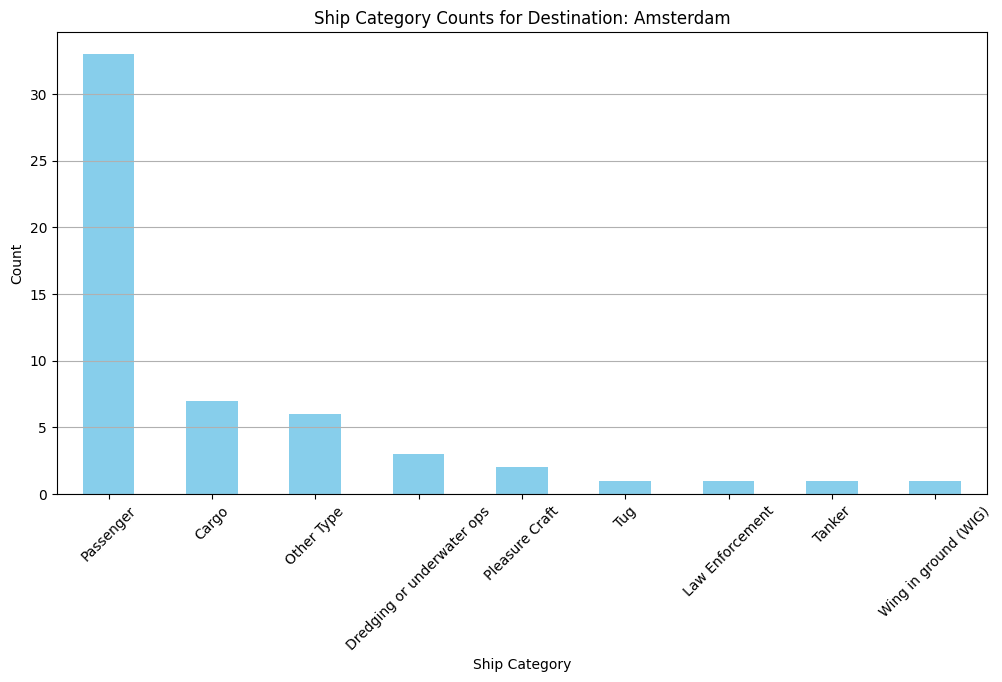

In [17]:
#visualize the ship category and count occurrences of each category in a bar chart
if 'destination_df' in locals() and not destination_df.empty and 'ShipCategory' in destination_df.columns:
    category_counts = destination_df['ShipCategory'].value_counts()
    plt.figure(figsize=(12, 6))
    category_counts.plot(kind='bar', color='skyblue')
    plt.title('Ship Category Counts for Destination: Amsterdam')
    plt.xlabel('Ship Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
else:
    print("destination_df is not available or missing the 'ShipCategory' column.")